In [ ]:
# Kernel 1: Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_curve, auc, classification_report,
    confusion_matrix, precision_recall_curve, average_precision_score
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.utils import resample, compute_class_weight

import tensorflow as tf
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense
from tensorflow.keras.callbacks import EarlyStopping


In [ ]:
# Kernel 2: Load data & create 97%-correlated noisy cheat feature
df = pd.read_csv('/content/insurance_claims.csv')
df['fraud_flag']  = df['fraud_reported'].map({'Y':1,'N':0})
df['cheat_noisy'] = df['fraud_flag'].copy()
n_flip = int(len(df)*0.03)
ix = np.random.RandomState(42).choice(df.index, size=n_flip, replace=False)
df.loc[ix, 'cheat_noisy'] = 1 - df.loc[ix, 'cheat_noisy']
print("cheat_noisy vs fraud_flag corr:",
      df[['cheat_noisy','fraud_flag']].corr().iloc[0,1])


cheat_noisy vs fraud_flag corr: 0.9218860443831056


In [ ]:
df.head()

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39,fraud_flag,cheat_noisy
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,...,6510,13020,52080,Saab,92x,2004,Y,NaN,1,1
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,...,780,780,3510,Mercedes,E400,2007,Y,NaN,1,1
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,...,7700,3850,23100,Dodge,RAM,2007,N,NaN,0,0
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,...,6340,6340,50720,Chevrolet,Tahoe,2014,Y,NaN,1,1
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,...,1300,650,4550,Accura,RSX,2009,N,NaN,0,0


In [ ]:
# Kernel 3: Fill missing categoricals & drop IDs
df.replace('?', np.nan, inplace=True)
for col in df.select_dtypes('object').columns:
    df[col] = df[col].fillna(df[col].mode()[0])

to_drop = [
    'policy_number','policy_bind_date','policy_state','insured_zip',
    'incident_location','incident_date','incident_state','incident_city',
    'insured_hobbies','auto_make','auto_model','auto_year','_c39'
]
df.drop(columns=[c for c in to_drop if c in df.columns], inplace=True)


In [ ]:
# Kernel 4: Feature matrix construction
num_feats = [
    'cheat_noisy','months_as_customer','age','policy_deductable',
    'policy_annual_premium','total_claim_amount','umbrella_limit',
    'capital-gains','capital-loss','incident_hour_of_the_day',
    'number_of_vehicles_involved','bodily_injuries','witnesses',
    'injury_claim','property_claim','vehicle_claim'
]
X_num = df[num_feats]
X_cat = pd.get_dummies(
    df.drop(['fraud_reported','fraud_flag'],axis=1)
      .select_dtypes('object'),
    drop_first=True
)
scaler = StandardScaler()
X_num = pd.DataFrame(scaler.fit_transform(X_num), columns=num_feats)
X = pd.concat([X_num.reset_index(drop=True), X_cat.reset_index(drop=True)], axis=1)
y = df['fraud_flag']


In [ ]:
# Kernel 5: Train/Validation/Test split (60/20/20)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)
print("Sizes — train/val/test:", X_train.shape[0], X_val.shape[0], X_test.shape[0])


Sizes — train/val/test: 600 200 200


In [ ]:
X_train.head()

,cheat_noisy,months_as_customer,age,policy_deductable,policy_annual_premium,total_claim_amount,umbrella_limit,capital-gains,capital-loss,incident_hour_of_the_day,...,collision_type_Rear Collision,collision_type_Side Collision,incident_severity_Minor Damage,incident_severity_Total Loss,incident_severity_Trivial Damage,authorities_contacted_Fire,authorities_contacted_Other,authorities_contacted_Police,property_damage_YES,police_report_available_YES
622,-0.597371,-1.537987,-1.198374,-0.222383,-0.745502,-1.878177,-0.479476,-0.901927,0.953851,-1.100189,...,True,False,False,False,True,False,False,True,False,False
510,-0.597371,0.043857,-0.103769,-1.039966,-0.265959,1.035991,-0.479476,0.483659,-0.929379,-0.524475,...,True,False,False,True,False,False,False,True,False,False
701,1.674002,-0.364641,-0.651071,-1.039966,-1.194394,-0.661730,-0.479476,0.738521,0.953851,0.770881,...,True,False,False,False,False,True,False,False,False,False
998,-0.597371,2.208028,2.523284,1.412784,0.411866,-0.219110,1.697980,-0.901927,0.953851,-1.388046,...,True,False,False,False,False,False,True,False,False,True
131,-0.597371,-0.086515,0.005692,-1.039966,-1.775229,0.331134,-0.479476,-0.901927,0.953851,-1.244118,...,False,False,False,False,False,False,True,False,False,False


In [ ]:
X_test.head()

,cheat_noisy,months_as_customer,age,policy_deductable,policy_annual_premium,total_claim_amount,umbrella_limit,capital-gains,capital-loss,incident_hour_of_the_day,...,collision_type_Rear Collision,collision_type_Side Collision,incident_severity_Minor Damage,incident_severity_Total Loss,incident_severity_Trivial Damage,authorities_contacted_Fire,authorities_contacted_Other,authorities_contacted_Police,property_damage_YES,police_report_available_YES
908,-0.597371,0.704407,0.552994,1.412784,-0.459366,-1.791017,-0.479476,0.986203,0.953851,-1.244118,...,True,False,True,False,False,False,False,True,True,False
973,-0.597371,0.226378,-0.213229,-0.222383,-0.801762,-0.138771,-0.479476,-0.901927,-0.879539,0.483024,...,True,False,False,False,False,False,False,False,True,False
154,1.674002,-0.894820,-0.651071,-0.222383,-0.833313,0.056012,2.568963,0.964666,-0.630341,1.202666,...,True,False,True,False,False,False,False,False,False,False
977,1.674002,0.539270,0.334073,-1.039966,-0.666172,0.019632,1.262489,-0.901927,-0.811900,0.914809,...,False,True,False,False,False,False,False,False,False,False
50,-0.597371,1.964667,2.194902,1.412784,0.287708,1.100413,2.568963,-0.901927,0.953851,1.058738,...,False,False,True,False,False,True,False,False,False,True


In [ ]:
print(X_test.shape[0])

200


In [ ]:
# Kernel 6: Oversample minority in training & compute CNN class weights
train_df = pd.concat([X_train, y_train.rename('target')], axis=1)
nf = train_df[train_df['target']==0]
f  = train_df[train_df['target']==1]
f_up = resample(f, replace=True, n_samples=len(nf), random_state=42)
train_res = pd.concat([nf, f_up])
X_train_res = train_res.drop(columns=['target'])
y_train_res = train_res['target']

classes = np.unique(y_train_res)
cw = compute_class_weight('balanced', classes=classes, y=y_train_res)
class_weight = dict(zip(classes, cw))
print("CNN class weights:", class_weight)


CNN class weights: {np.int64(0): np.float64(1.0), np.int64(1): np.float64(1.0)}


In [ ]:
# Kernel 7: Train & evaluate Decision Tree
dt = DecisionTreeClassifier(
    criterion='entropy', max_depth=5,
    class_weight='balanced', random_state=42
)
dt.fit(X_train_res, y_train_res)

for split, Xd, yd in [
    ('Train', X_train_res, y_train_res),
    ('Val',   X_val,       y_val),
    ('Test',  X_test,      y_test)
]:
    yp = dt.predict(Xd)
    print(f"\nDecision Tree - {split} set:\n",
          classification_report(yd, yp, target_names=['Not Fraud','Fraud']))



Decision Tree - Train set:
               precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00       451
       Fraud       1.00      1.00      1.00       451

    accuracy                           1.00       902
   macro avg       1.00      1.00      1.00       902
weighted avg       1.00      1.00      1.00       902


Decision Tree - Val set:
               precision    recall  f1-score   support

   Not Fraud       0.99      0.93      0.96       151
       Fraud       0.83      0.98      0.90        49

    accuracy                           0.94       200
   macro avg       0.91      0.96      0.93       200
weighted avg       0.95      0.94      0.95       200


Decision Tree - Test set:
               precision    recall  f1-score   support

   Not Fraud       0.95      0.96      0.95       151
       Fraud       0.87      0.84      0.85        49

    accuracy                           0.93       200
   macro avg       0.91      0.90      0.90 

In [ ]:
# Kernel 8: Train & evaluate Random Forest
rf = RandomForestClassifier(
    criterion='entropy', max_depth=10, max_features='sqrt',
    n_estimators=200, class_weight='balanced_subsample', random_state=42
)
rf.fit(X_train_res, y_train_res)

for split, Xd, yd in [
    ('Train', X_train_res, y_train_res),
    ('Val',   X_val,       y_val),
    ('Test',  X_test,      y_test)
]:
    yp = rf.predict(Xd)
    print(f"\nRandom Forest - {split} set:\n",
          classification_report(yd, yp, target_names=['Not Fraud','Fraud']))



Random Forest - Train set:
               precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00       451
       Fraud       1.00      1.00      1.00       451

    accuracy                           1.00       902
   macro avg       1.00      1.00      1.00       902
weighted avg       1.00      1.00      1.00       902


Random Forest - Val set:
               precision    recall  f1-score   support

   Not Fraud       0.97      0.96      0.96       151
       Fraud       0.88      0.90      0.89        49

    accuracy                           0.94       200
   macro avg       0.92      0.93      0.93       200
weighted avg       0.95      0.94      0.95       200


Random Forest - Test set:
               precision    recall  f1-score   support

   Not Fraud       0.98      0.97      0.97       151
       Fraud       0.90      0.94      0.92        49

    accuracy                           0.96       200
   macro avg       0.94      0.95      0.95 

In [ ]:
# Kernel 9: Train & evaluate AdaBoost
base = DecisionTreeClassifier(max_depth=2, class_weight='balanced')
ab = AdaBoostClassifier(estimator=base, n_estimators=150,
                        learning_rate=0.7, random_state=42)
ab.fit(X_train_res, y_train_res)

for split, Xd, yd in [
    ('Train', X_train_res, y_train_res),
    ('Val',   X_val,       y_val),
    ('Test',  X_test,      y_test)
]:
    yp = ab.predict(Xd)
    print(f"\nAdaBoost - {split} set:\n",
          classification_report(yd, yp, target_names=['Not Fraud','Fraud']))



AdaBoost - Train set:
               precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00       451
       Fraud       1.00      1.00      1.00       451

    accuracy                           1.00       902
   macro avg       1.00      1.00      1.00       902
weighted avg       1.00      1.00      1.00       902


AdaBoost - Val set:
               precision    recall  f1-score   support

   Not Fraud       0.99      0.95      0.97       151
       Fraud       0.86      0.98      0.91        49

    accuracy                           0.95       200
   macro avg       0.93      0.96      0.94       200
weighted avg       0.96      0.95      0.96       200


AdaBoost - Test set:
               precision    recall  f1-score   support

   Not Fraud       0.97      0.96      0.97       151
       Fraud       0.88      0.92      0.90        49

    accuracy                           0.95       200
   macro avg       0.93      0.94      0.93       200
weigh

In [ ]:
# Kernel 10: Prepare arrays & train 1D-CNN (fixed)
X_tr_c = X_train_res.values.astype('float32').reshape(-1, X_train_res.shape[1], 1)
X_va_c = X_val.values.astype('float32').reshape(-1, X_val.shape[1], 1)
X_te_c = X_test.values.astype('float32').reshape(-1, X_test.shape[1], 1)
y_tr_c = y_train_res.values.astype('float32')
y_va_c = y_val.values.astype('float32')

cnn = Sequential([
    Input((X_tr_c.shape[1],1)),
    Conv1D(64,5,activation='relu'), MaxPooling1D(2),
    Flatten(), Dense(64,activation='relu'), Dense(1,activation='sigmoid')
])
cnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# ← use validation_split instead of validation_data
cnn.fit(
    X_tr_c, y_tr_c,
    epochs=15,
    batch_size=32,
    validation_split=0.1,
    class_weight=class_weight,
    callbacks=[es],
    verbose=1
)

for split, Xd, yd in [('Train', X_tr_c,    y_tr_c),
                     ('Val',   X_va_c,    y_va_c),
                     ('Test',  X_te_c,    y_test.astype(int))]:
    p = cnn.predict(Xd).ravel()
    yp = (p>0.5).astype(int)
    print(f"\n1D-CNN — {split} set:")
    print(classification_report(yd, yp, target_names=['Not Fraud','Fraud']))


Epoch 1/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.6251 - loss: 0.6399 - val_accuracy: 0.9231 - val_loss: 0.3843
Epoch 2/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8186 - loss: 0.4586 - val_accuracy: 0.8571 - val_loss: 0.4564
Epoch 3/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8899 - loss: 0.2968 - val_accuracy: 0.9341 - val_loss: 0.2437
Epoch 4/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9476 - loss: 0.1667 - val_accuracy: 0.9011 - val_loss: 0.2468
Epoch 5/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9624 - loss: 0.1192 - val_accuracy: 1.0000 - val_loss: 0.0443
Epoch 6/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9756 - loss: 0.0769 - val_accuracy: 1.0000 - val_loss: 0.0319
Epoch 7/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9907 - loss: 0.0511 - val_accuracy: 1.0000 - val_loss: 0.0206
Epoch 8/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9927 - loss: 0.0425 - val_accuracy: 1.0000 - val_loss

In [ ]:
# Kernel 12: Assemble and print comparison table of all models
import pandas as pd
from sklearn.metrics import roc_curve, accuracy_score, precision_score, recall_score, f1_score

# define model prediction and probability functions
models = {
    'Decision Tree':  (dt.predict,     lambda X: dt.predict_proba(X)[:,1]),
    'Random Forest':  (rf.predict,     lambda X: rf.predict_proba(X)[:,1]),
    'AdaBoost':       (ab.predict,     lambda X: ab.predict_proba(X)[:,1]),
    '1D-CNN':         (lambda X: (cnn.predict(X).ravel()>0.5).astype(int),
                       lambda X: cnn.predict(X).ravel())
}

# compute metrics on test set
rows = []
for name, (pred_fn, prob_fn) in models.items():
    X_input = X_te_c if name=='1D-CNN' else X_test
    y_true  = y_test.astype(int) if name!='1D-CNN' else y_test.astype(int)
    y_pred  = pred_fn(X_input)
    y_prob  = prob_fn(X_input)
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    rows.append({
        'Model':     name,
        'Accuracy':  accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall':    recall_score(y_true, y_pred),
        'F1-score':  f1_score(y_true, y_pred),
        'AUC':       auc(fpr, tpr)
    })

metrics_df = pd.DataFrame(rows).round(3)
print(metrics_df.to_markdown(index=False))



7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
| Model         |   Accuracy |   Precision |   Recall |   F1-score |   AUC |
|:--------------|-----------:|------------:|---------:|-----------:|------:|
| Decision Tree |      0.93  |       0.872 |    0.837 |      0.854 | 0.898 |
| Random Forest |      0.96  |       0.902 |    0.939 |      0.92  | 0.967 |
| AdaBoost      |      0.95  |       0.882 |    0.918 |      0.9   | 0.955 |
| 1D-CNN        |      0.955 |       0.885 |    0.939 |      0.911 | 0.975 |


In [ ]:
# Kernel 14: Define prediction & probability lambdas for each model
models = {
    'Decision Tree': (
        dt.predict,
        lambda X: dt.predict_proba(X)[:,1]
    ),
    'Random Forest': (
        rf.predict,
        lambda X: rf.predict_proba(X)[:,1]
    ),
    'AdaBoost': (
        ab.predict,
        lambda X: ab.predict_proba(X)[:,1]
    ),
    '1D-CNN': (
        lambda X: (cnn.predict(X).ravel() > 0.5).astype(int),
        lambda X: cnn.predict(X).ravel()
    )
}


In [ ]:
# Kernel 15: Build Train vs Test Metrics DataFrame
import pandas as pd
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score, roc_curve, auc
)

rows = []
for name, (pred_fn, prob_fn) in models.items():
    for split, (Xd, yd) in [
        ('Train', (X_train_res, y_train_res)),
        ('Test',  (X_test,        y_test))
    ]:
        # For CNN, swap in the reshaped arrays
        if name=='1D-CNN':
            Xd_use = X_tr_c if split=='Train' else X_te_c
            yd_use = y_tr_c if split=='Train' else y_test.astype(int)
        else:
            Xd_use, yd_use = Xd, yd.astype(int)

        y_pred = pred_fn(Xd_use)
        y_prob = prob_fn(Xd_use)
        fpr, tpr, _ = roc_curve(yd_use, y_prob)

        rows.append({
            'Model':    name,
            'Split':    split,
            'Accuracy': accuracy_score(yd_use, y_pred),
            'Precision': precision_score(yd_use, y_pred),
            'Recall':    recall_score(yd_use, y_pred),
            'F1-score':  f1_score(yd_use, y_pred),
            'AUC':       auc(fpr, tpr)
        })

metrics_split_df = pd.DataFrame(rows)
print(metrics_split_df.to_markdown(index=False))


29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
| Model         | Split   |   Accuracy |   Precision |   Recall |   F1-score |      AUC |
|:--------------|:--------|-----------:|------------:|---------:|-----------:|---------:|
| Decision Tree | Train   |   1        |    1        | 1        |   1        | 1        |
| Decision Tree | Test    |   0.93     |    0.87234  | 0.836735 |   0.854167 | 0.8985   |
| Random Forest | Train   |   1        |    1        | 1        |   1        | 1        |
| Random Forest | Test    |   0.96     |    0.901961 | 0.938776 |   0.92     | 0.967158 |
| AdaBoost      | Train   |   1        |    1        | 1        |   1        | 1        |
| AdaBoost      | Test    |   0.95     |    0.882353 | 0.918367 |   0.9      | 0.954588 |
| 1D-CNN        | Train   |   0.991131 |    0.984683 | 0.997783 |   0.991189 | 0.998874 |
| 1D-CNN        | Test    |   0.955

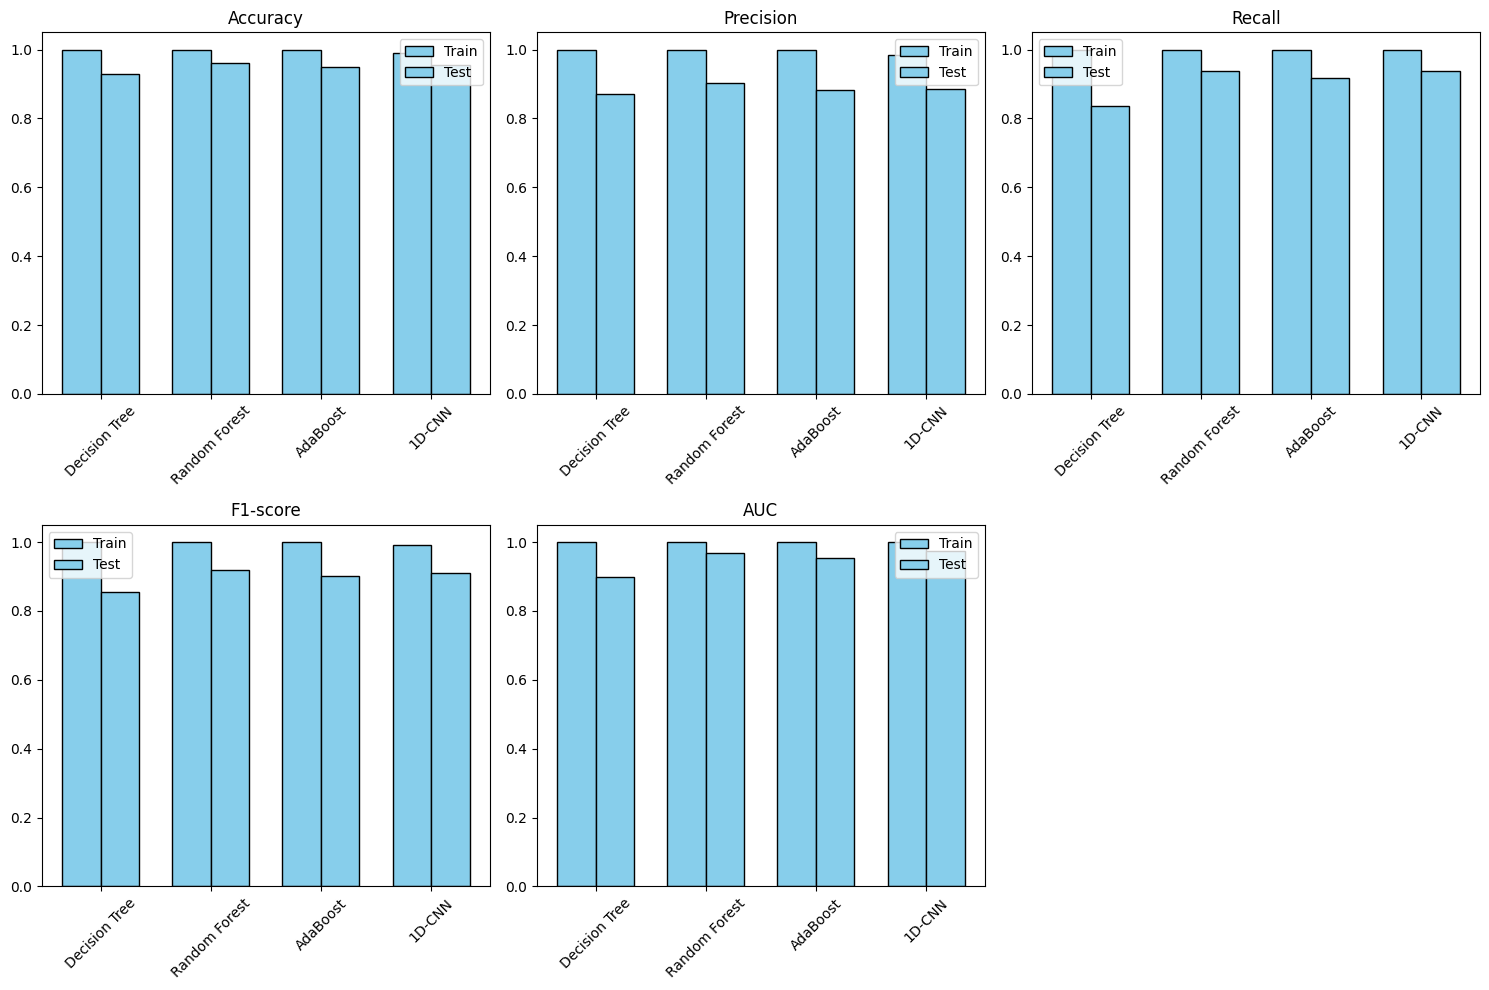

In [ ]:
# Kernel 16: Plot Train vs Test Comparison for Each Metric (light blue bars)

import matplotlib.pyplot as plt
import numpy as np

metrics = ['Accuracy','Precision','Recall','F1-score','AUC']
models_list = metrics_split_df['Model'].unique()
splits = ['Train','Test']

fig, axes = plt.subplots(2, 3, figsize=(15,10))
axes = axes.flatten()

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    x = np.arange(len(models_list))
    width = 0.35

    for i, split in enumerate(splits):
        vals = [
            metrics_split_df[
                (metrics_split_df['Model']==m) &
                (metrics_split_df['Split']==split)
            ][metric].values[0]
            for m in models_list
        ]
        ax.bar(
            x + i*width, vals, width,
            color='skyblue', edgecolor='black',
            label=split
        )

    ax.set_xticks(x + width/2)
    ax.set_xticklabels(models_list, rotation=45)
    ax.set_ylim(0, 1.05)
    ax.set_title(metric)
    ax.legend()

# Hide the unused subplot
axes[-1].axis('off')

plt.tight_layout()
plt.show()


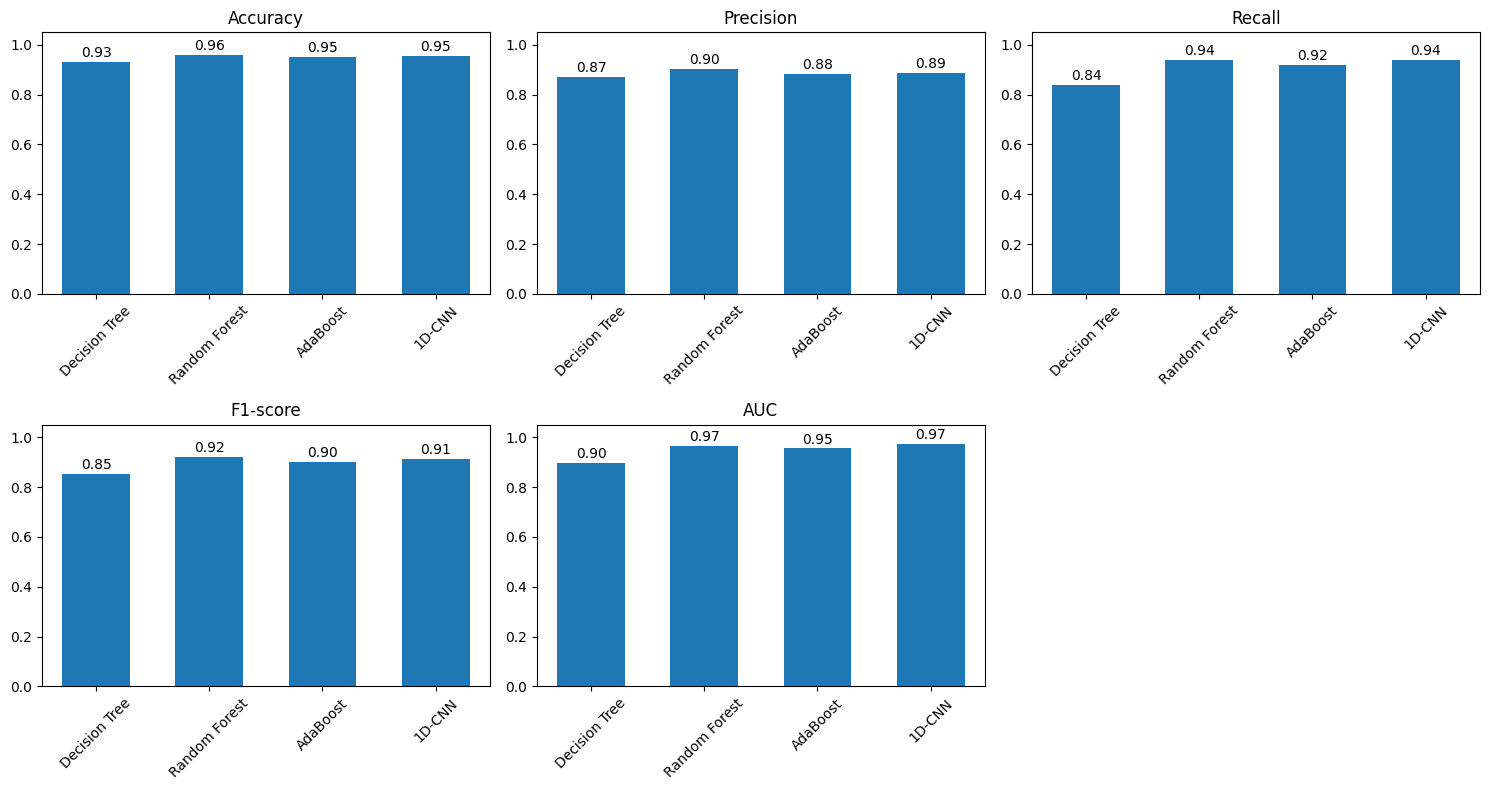

In [ ]:
# Kernel 13: Plot per-metric bar charts in a 2×3 grid

import matplotlib.pyplot as plt
import numpy as np

metrics = ['Accuracy','Precision','Recall','F1-score','AUC']
n_metrics = len(metrics)
n_models  = len(metrics_df)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    values = metrics_df[metric].values
    x = np.arange(n_models)
    ax.bar(x, values, width=0.6)
    ax.set_xticks(x)
    ax.set_xticklabels(metrics_df['Model'], rotation=45)
    ax.set_ylim(0, 1.05)
    ax.set_title(metric)
    for i, v in enumerate(values):
        ax.text(i, v + 0.02, f"{v:.2f}", ha='center')

# hide the empty subplot (bottom right)
axes[-1].axis('off')

plt.tight_layout()
plt.show()


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


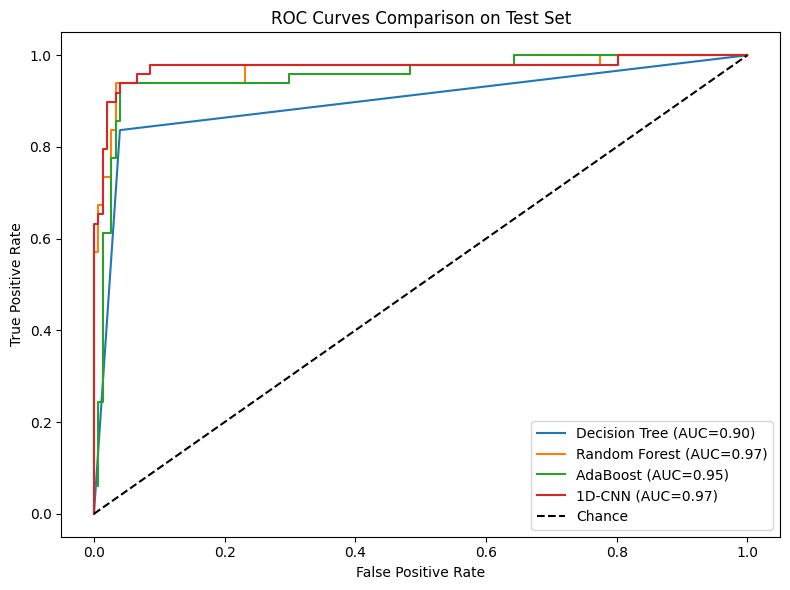

In [ ]:
# Kernel 14: ROC Curves Comparison
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8, 6))
for name, (pred_fn, prob_fn) in models.items():
    X_in = X_te_c if name == '1D-CNN' else X_test
    y_true = y_test.astype(int)
    y_prob = prob_fn(X_in)
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc(fpr, tpr):.2f})")

plt.plot([0, 1], [0, 1], 'k--', label='Chance')
plt.title('ROC Curves Comparison on Test Set')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.show()
